## 1: Exploratory Data Analysis (EDA):

In [190]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [191]:
# Load dataset
df = pd.read_csv("wine.csv")
# Data Explorations :
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [192]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [193]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [194]:
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

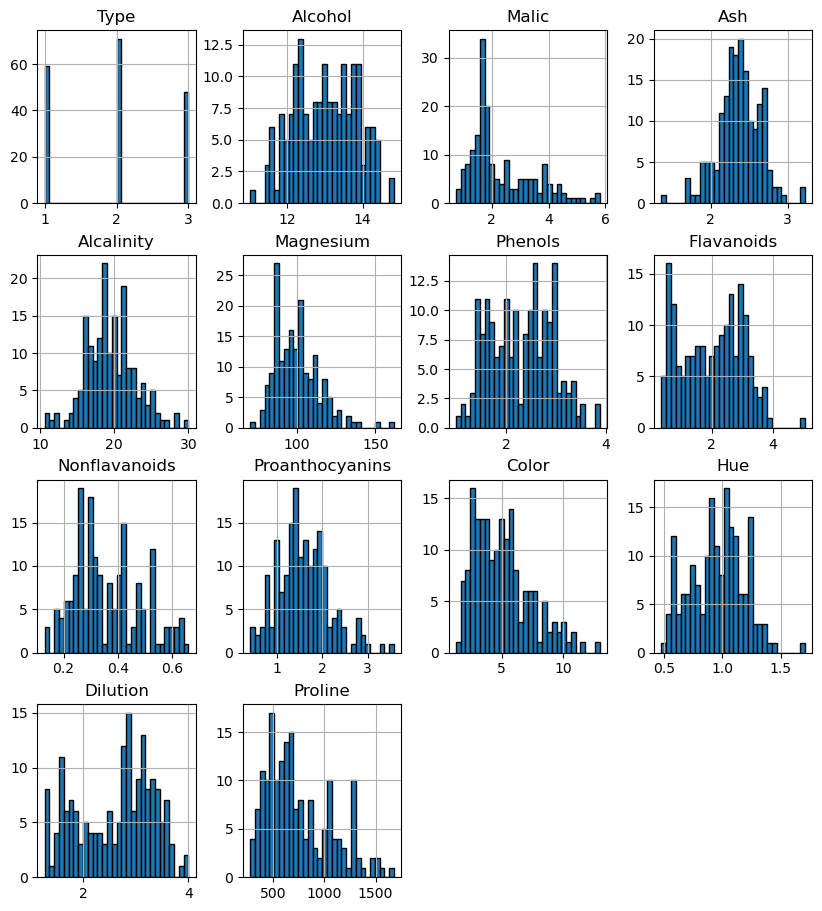

In [195]:
# Distribution of Features
    # Histogram:
df.hist(bins = 30 , figsize = (10,11) , edgecolor = 'black')
plt.show()

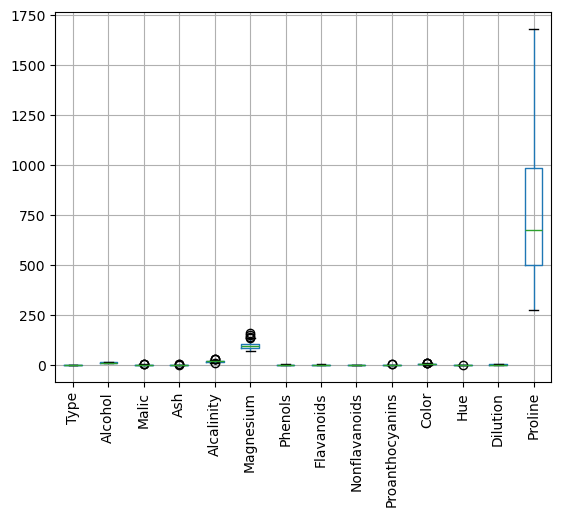

In [196]:
df.boxplot()
plt.xticks(rotation = 90)
plt.show()

In [197]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Treat (cap) outliers
    df[col] = df[col].clip(lower, upper)

print("Outliers detected and treated successfully.")

Outliers detected and treated successfully.


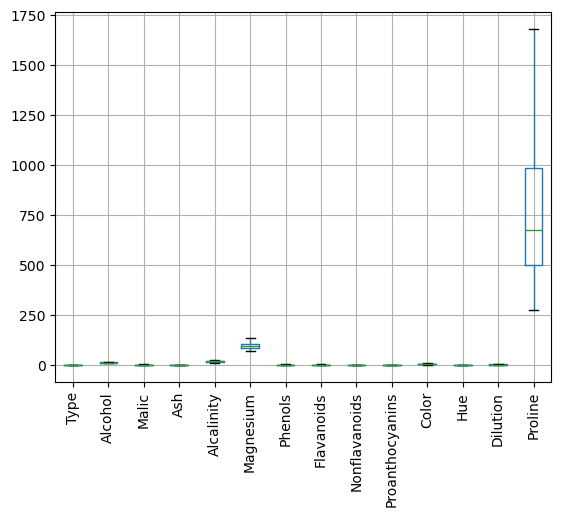

In [198]:
df.boxplot()
plt.xticks(rotation = 90)
plt.show()

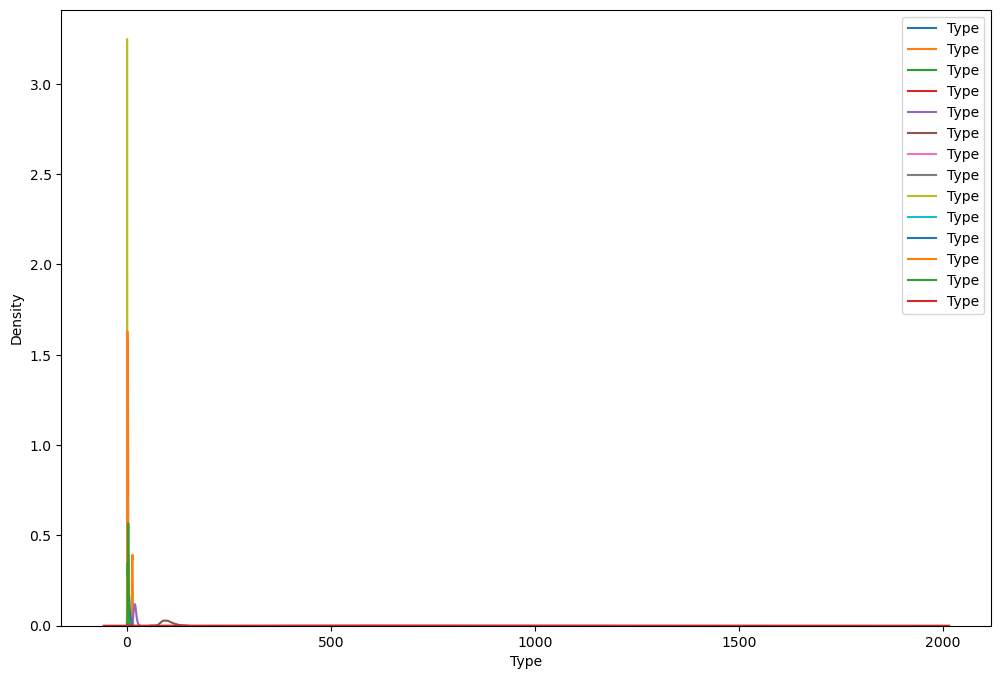

In [199]:
# density plot
plt.figure(figsize = (12,8))
for column in df.select_dtypes(include=['float64','int64']).columns:
    sns.kdeplot(df[column] , label = columns)
plt.legend()    
plt.show()

In [200]:
# Correlation matrix:
df.corr()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
Type,1.000000,-0.328222,0.440422,-0.047680,0.525608,-0.224264,-0.719163,-0.847498,0.489109,-0.512528,0.260260,-0.621549,-0.788230,-0.633717
Alcohol,-0.328222,1.000000,0.094756,0.220174,-0.312191,0.302173,0.289101,0.236815,-0.155929,0.153171,0.549107,-0.067156,0.072343,0.643720
Malic,0.440422,0.094756,1.000000,0.166614,0.295882,-0.039329,-0.339050,-0.414875,0.294203,-0.234575,0.264897,-0.566409,-0.372582,-0.191173
Ash,-0.047680,0.220174,0.166614,1.000000,0.427713,0.322510,0.124436,0.097562,0.183666,0.006080,0.256799,-0.075904,-0.011214,0.229676
Alcalinity,0.525608,-0.312191,0.295882,0.427713,1.000000,-0.098030,-0.333046,-0.363405,0.369276,-0.208794,0.009748,-0.286664,-0.287032,-0.448700
Magnesium,-0.224264,0.302173,-0.039329,0.322510,-0.098030,1.000000,0.227035,0.209431,-0.255674,0.201428,0.240505,0.040007,0.064019,0.411557
Phenols,-0.719163,0.289101,-0.339050,0.124436,-0.333046,0.227035,1.000000,0.864564,-0.449935,0.618771,-0.062101,0.435952,0.699949,0.498115
Flavanoids,-0.847498,0.236815,-0.414875,0.097562,-0.363405,0.209431,0.864564,1.000000,-0.537900,0.665384,-0.169807,0.546718,0.787194,0.494193
Nonflavanoids,0.489109,-0.155929,0.294203,0.183666,0.369276,-0.255674,-0.449935,-0.537900,1.000000,-0.368455,0.131596,-0.266995,-0.503270,-0.311385
Proanthocyanins,-0.512528,0.153171,-0.234575,0.006080,-0.208794,0.201428,0.618771,0.665384,-0.368455,1.000000,-0.032693,0.306289,0.530565,0.340562


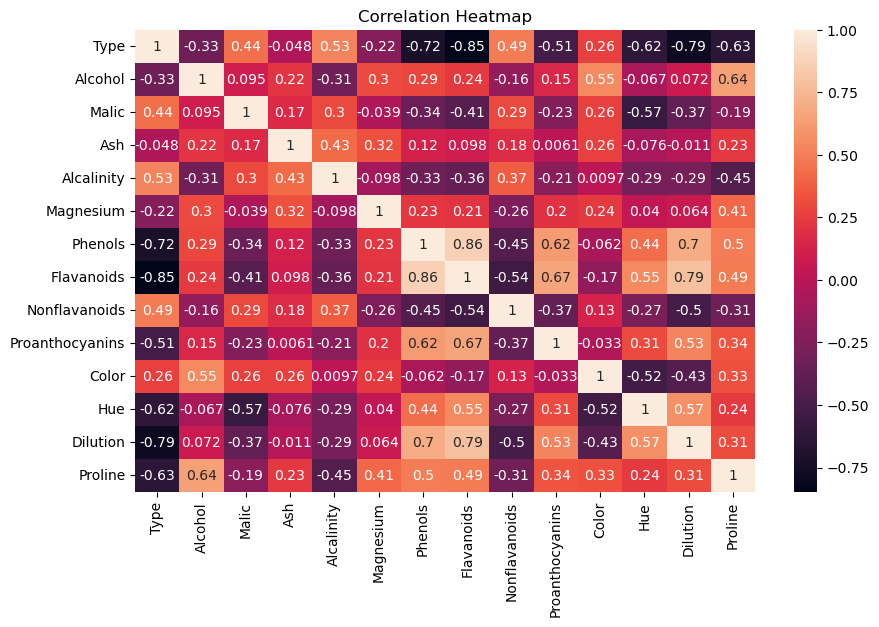

In [201]:
# HeatMap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr() , annot = True )
plt.title("Correlation Heatmap")
plt.show()

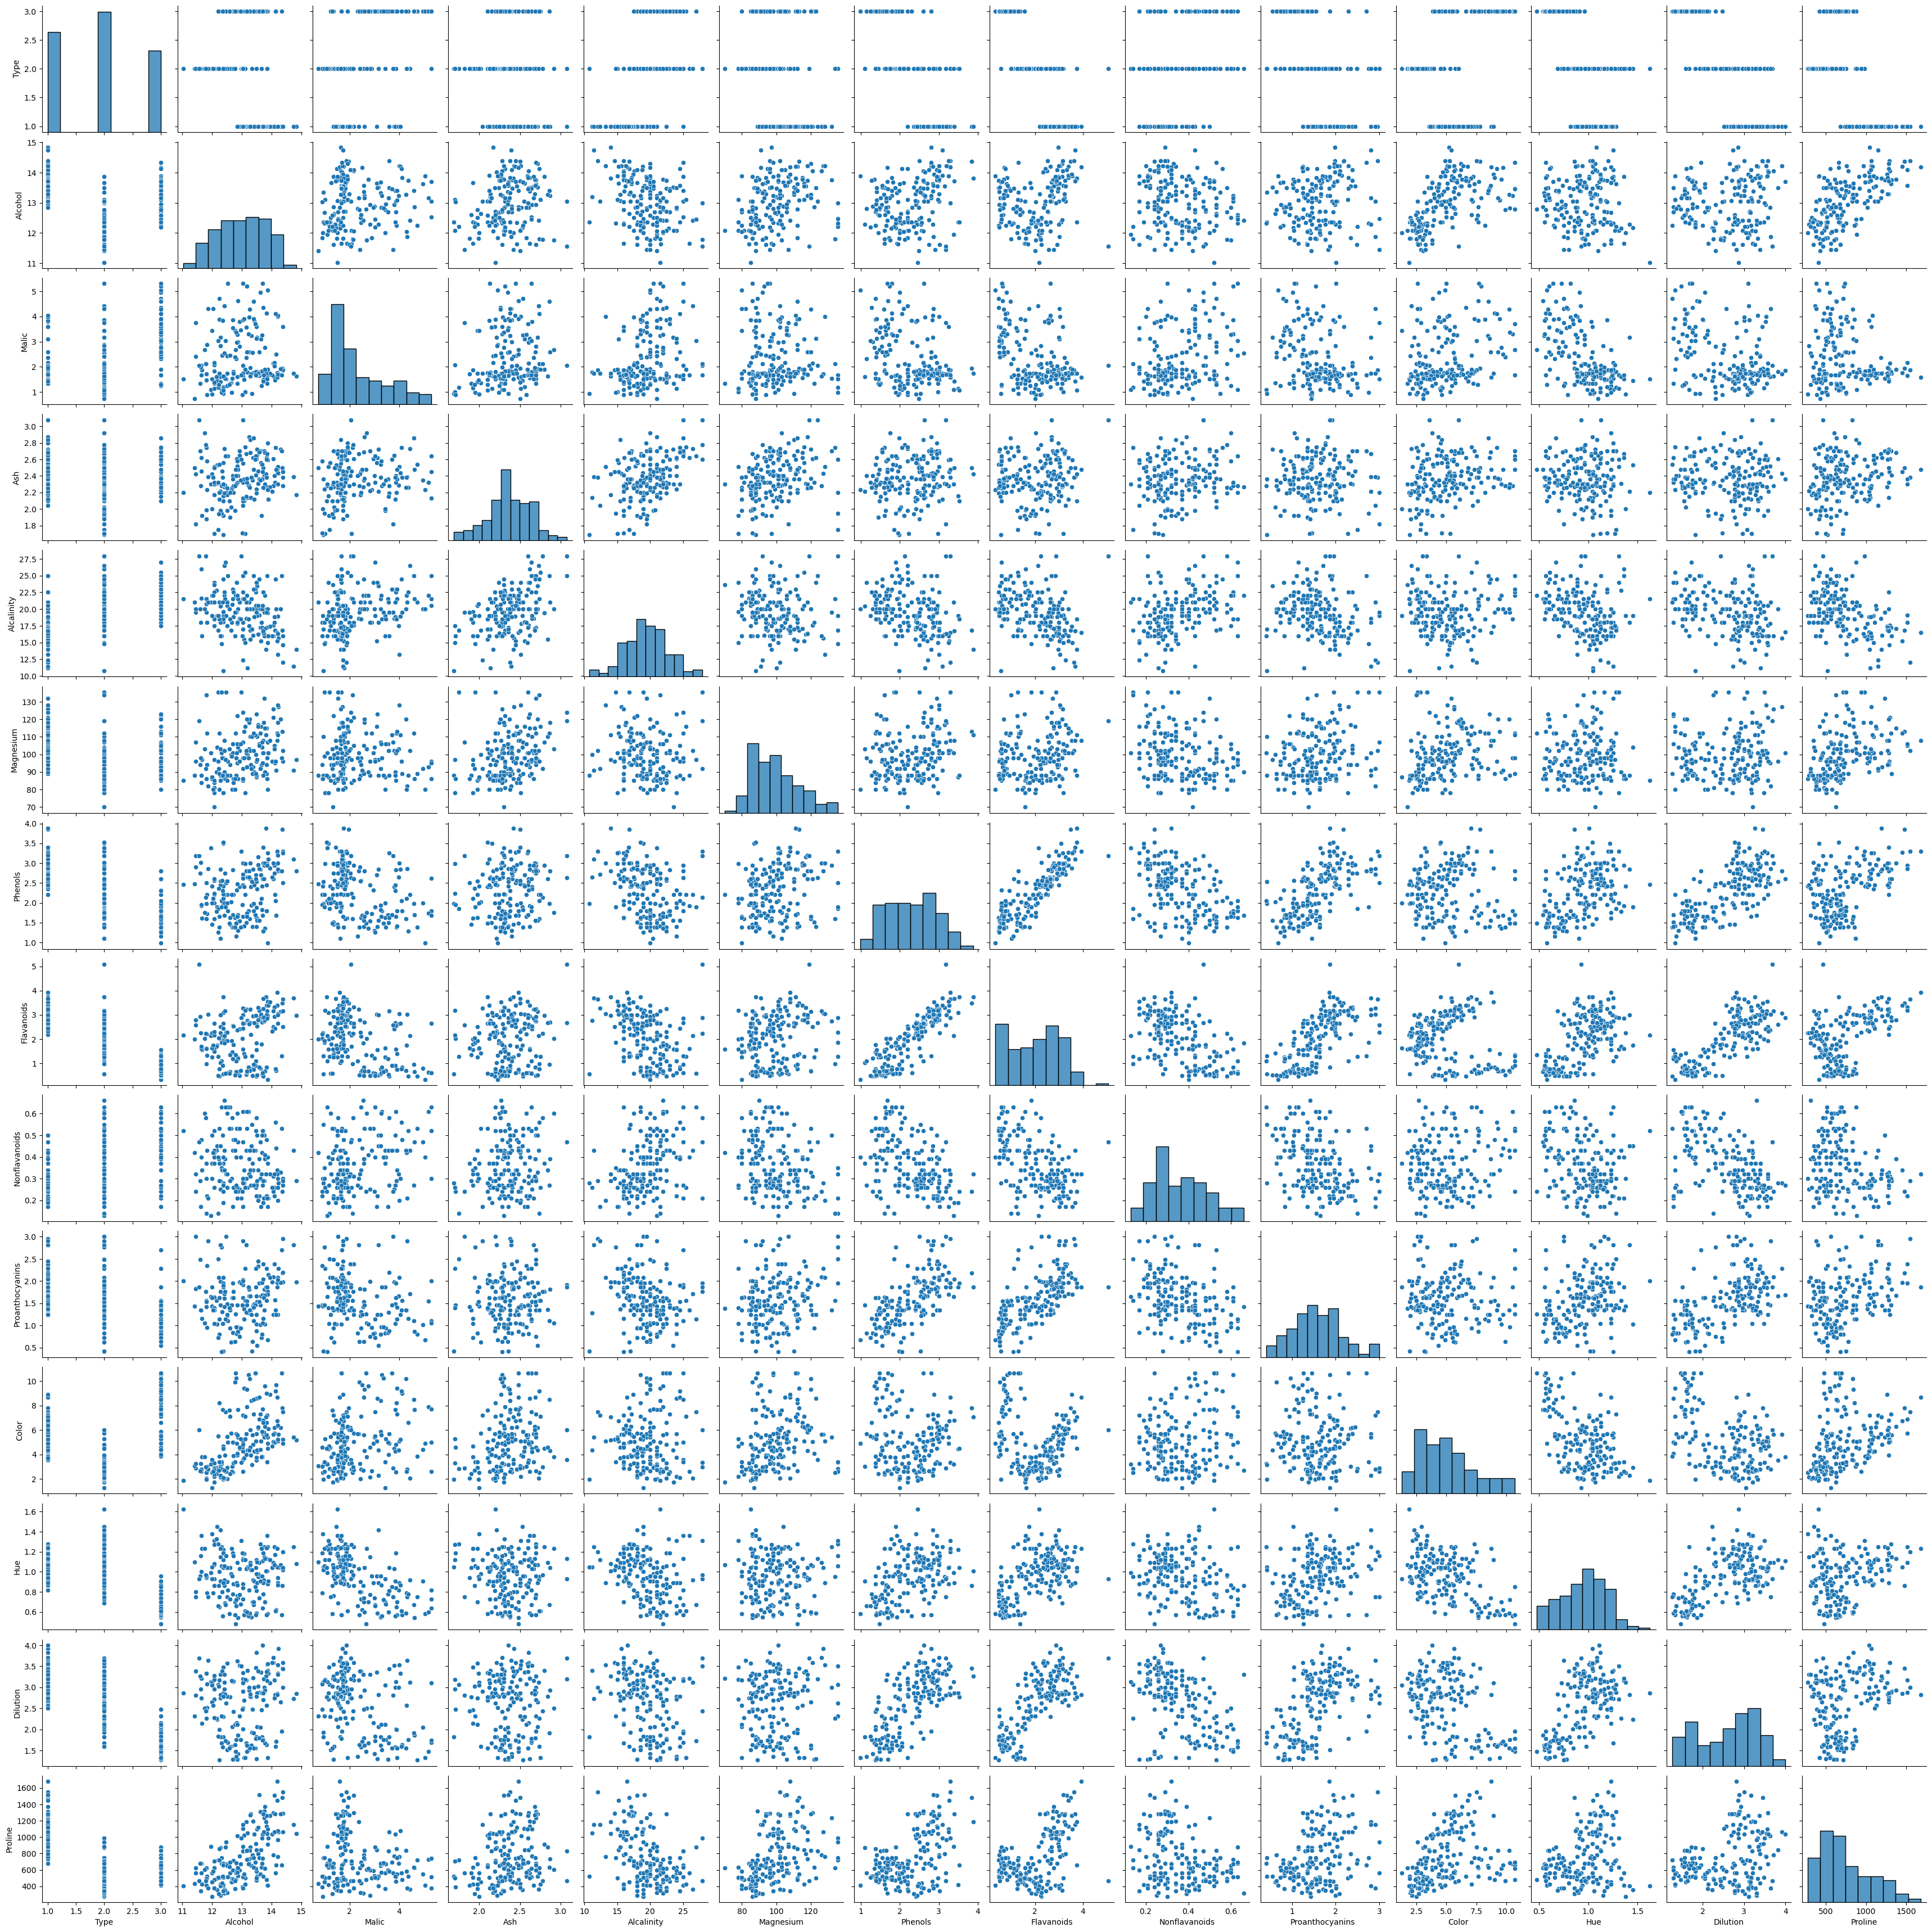

In [202]:
# pairplot

sns.pairplot(df)
plt.show()

## 2: Dimensionality Reduction with PCA:

In [203]:
# Standardize :
from sklearn.preprocessing import StandardScaler
    # only numeric columns
numeric_col = df.select_dtypes('int64','float64')

scaler = StandardScaler()
scaler_data = scaler.fit_transform(numeric_col)


In [237]:
# PCA
    # Apply pca
from sklearn.decomposition import PCA

pca = PCA()
pca_data = pca.fit_transform(scaler_data)


In [230]:
    # Variance Explained
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.81685839, 0.18314161])

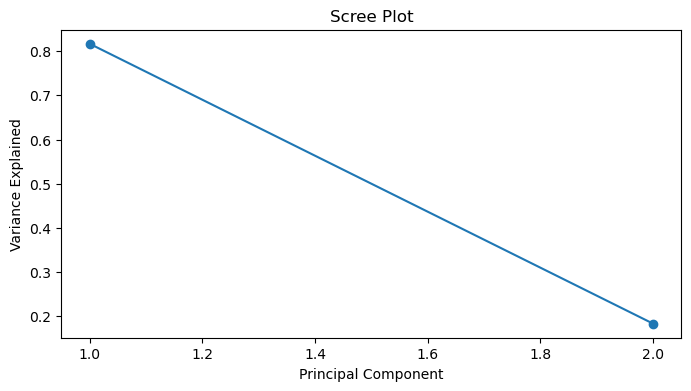

In [231]:
# scree plot
plt.figure(figsize=(8,4))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.show()

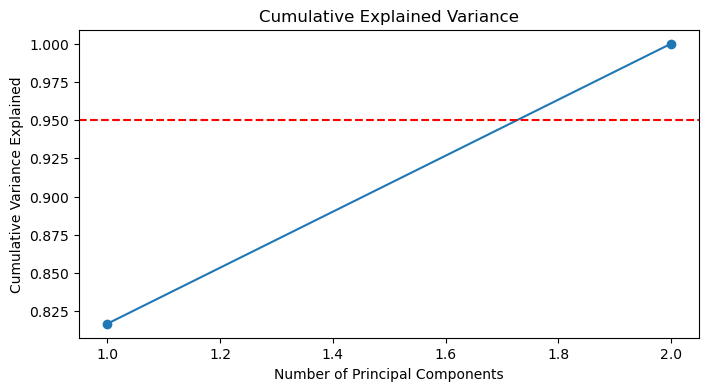

In [232]:
# Cumulative Explained Variance :
plt.figure(figsize=(8,4))
plt.plot(range(1, len(explained_variance)+1), np.cumsum(explained_variance), marker='o', linestyle='-')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.axhline(y=0.95, color='r', linestyle='--') # 95% threshold line
plt.show()

In [233]:
optimal_components = np.argmax(np.cumsum(explained_variance) >= 0.95) + 1
print("Optimal number of components (95% variance):", optimal_components)

Optimal number of components (95% variance): 2


In [239]:
    # Re-run PCA with Optimal Components :
pca_opt = PCA(n_components = optimal_components)
reduced_data = pca_opt.fit_transform(scaler_data)

pca_df = pd.DataFrame(reduced_data, columns=[f'PC{i+1}' for i in range(2)])
pca_df.head()

,PC1,PC2
0,-1.574693,-0.142082
1,-1.540917,-0.175859
2,-1.844907,0.128131
3,-2.509181,0.792405
4,-0.831607,-0.885169


## 3: Clustering with Original Data:

In [227]:
# Apply K-Means: Elbow Method
from sklearn.cluster import KMeans
inertia = []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i)
    kmeans.fit(scaler_data)
    inertia.append(kmeans.inertia_)
print(inertia)

[355.9999999999999, 103.93660507888902, 52.36174772683317, 32.844291581920366, 27.753756306500783, 17.465111058925977, 13.30171656567274, 9.49372571356082, 7.313853160135193, 6.846293400370634]


Text(0.5, 1.0, 'Elbow method')

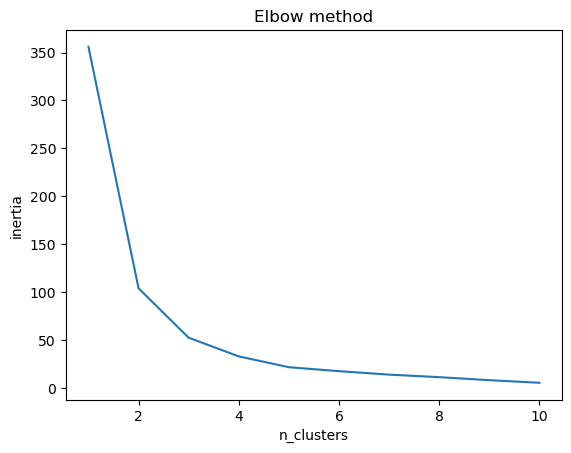

In [211]:
plt.plot(range(1,11),inertia)
plt.xlabel("n_clusters")
plt.ylabel("inertia")
plt.title("Elbow method")

In [212]:
k_means = KMeans(n_clusters=3, random_state=42)
labels_kmeans = k_means.fit_predict(scaler_data)
df['Cluster_KMeans'] = labels_kmeans
df['Cluster_KMeans']

0      1
1      1
2      2
3      2
4      1
      ..
173    0
174    0
175    0
176    0
177    0
Name: Cluster_KMeans, Length: 178, dtype: int32

In [213]:
df['Cluster_KMeans'].value_counts()

Cluster_KMeans
0    117
1     38
2     23
Name: count, dtype: int64

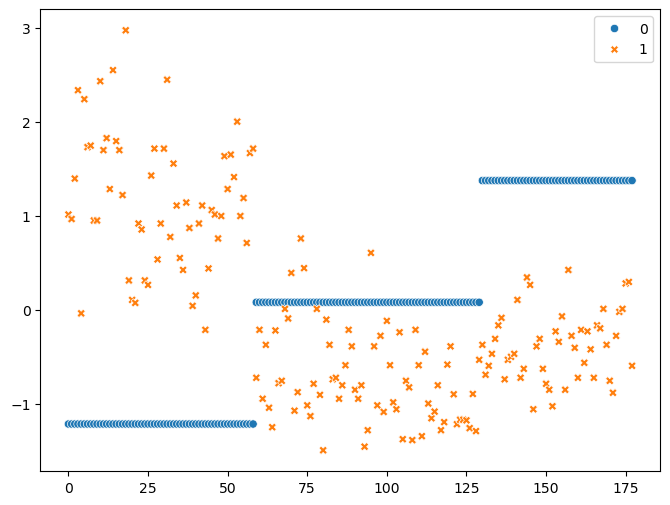

In [214]:
# Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(data=scaler_data)
plt.show()

In [215]:
# Evaluate Clusters
    # silhouette score
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(scaler_data, labels_kmeans)
sil_score

np.float64(0.5621195852013563)

In [216]:
    # Davies–Bouldin index
from sklearn.metrics import davies_bouldin_score

db_index = davies_bouldin_score(scaler_data, labels_kmeans)
print("Davies–Bouldin Index:", db_index)


Davies–Bouldin Index: 0.6021469363349591


## 4: Clustering with PCA Data:

In [240]:
# Apply K-Means: Elbow Method with PCA-Data
inertia_pca=[]
for i in range(1,11):
    kmeans_pca=KMeans(n_clusters=i)
    kmeans_pca.fit(pca_df)
    inertia_pca.append(kmeans_pca.inertia_)
print(inertia_pca)

[355.9999999999999, 103.936605078889, 52.30936325377661, 32.913155431314976, 21.59987180775527, 17.496959567904128, 13.301716565672738, 9.49372571356082, 9.512140691854388, 5.720113464272801]


Text(0.5, 1.0, 'Elbow method')

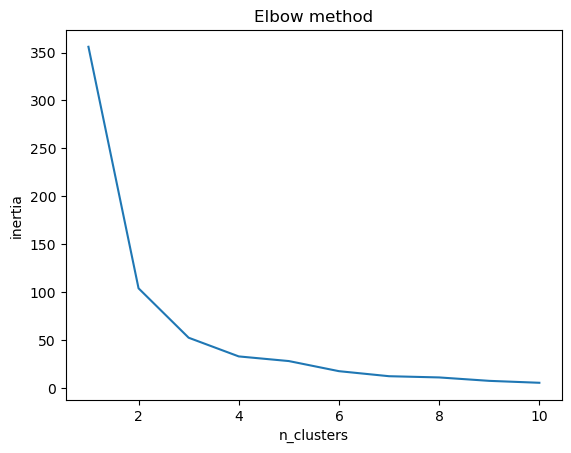

In [218]:
plt.plot(range(1,11),inertia_pca)
plt.xlabel("n_clusters")
plt.ylabel("inertia")
plt.title("Elbow method")

In [241]:
k_means_pca = KMeans(n_clusters=3, random_state=42)
labels_kmeans_pca = k_means_pca.fit_predict(pca_df)
df['Cluster_KMeans_PCA'] = labels_kmeans_pca
df['Cluster_KMeans_PCA']

0      1
1      1
2      2
3      2
4      1
      ..
173    0
174    0
175    0
176    0
177    0
Name: Cluster_KMeans_PCA, Length: 178, dtype: int32

In [220]:
df['Cluster_KMeans_PCA'].value_counts()

Cluster_KMeans_PCA
0    117
1     38
2     23
Name: count, dtype: int64

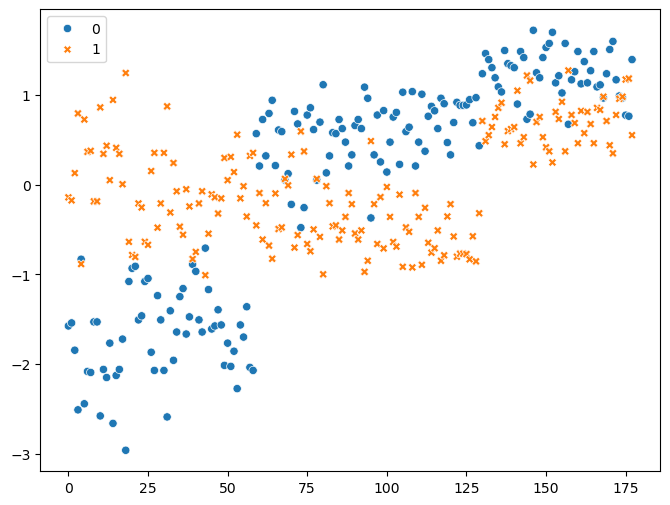

In [247]:
# Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_data)
plt.show()

In [243]:
from sklearn.metrics import silhouette_score
silh_score = silhouette_score(pca_df, labels_kmeans_pca)
silh_score

np.float64(0.562119585201356)

In [244]:
    # Davies–Bouldin index
from sklearn.metrics import davies_bouldin_score

db_index = davies_bouldin_score(pca_df, labels_kmeans_pca)
print("Davies–Bouldin Index:", db_index)


Davies–Bouldin Index: 0.6021469363349605


## 5: Comparison and Analysis:

The silhouette scores for clustering using the original dataset and the PCA-transformed dataset were nearly the same. This indicates that PCA preserved the key structure and separation of data points. Hence, dimensionality reduction did not significantly affect the cluster quality, while it simplified the data representation and visualization.

PCA reduced noise and redundant features, which slightly improved cluster compactness in some cases (though silhouette improvement may be small).

PCA mainly helped in visualization and reducing computation, not in changing cluster quality.

## 6: Conclusion and Insights

PCA reduced the data size while keeping most of the important information, and clustering results remained similar before and after PCA.

PCA reduced the data size while keeping most of the important information, and clustering results remained similar before and after PCA.

Use PCA when the dataset has many correlated features; otherwise, clustering on the original data is sufficient.